[SUKCES] Zapisano wartości do pliku: pelny_wektor_hog_zalacznik.txt



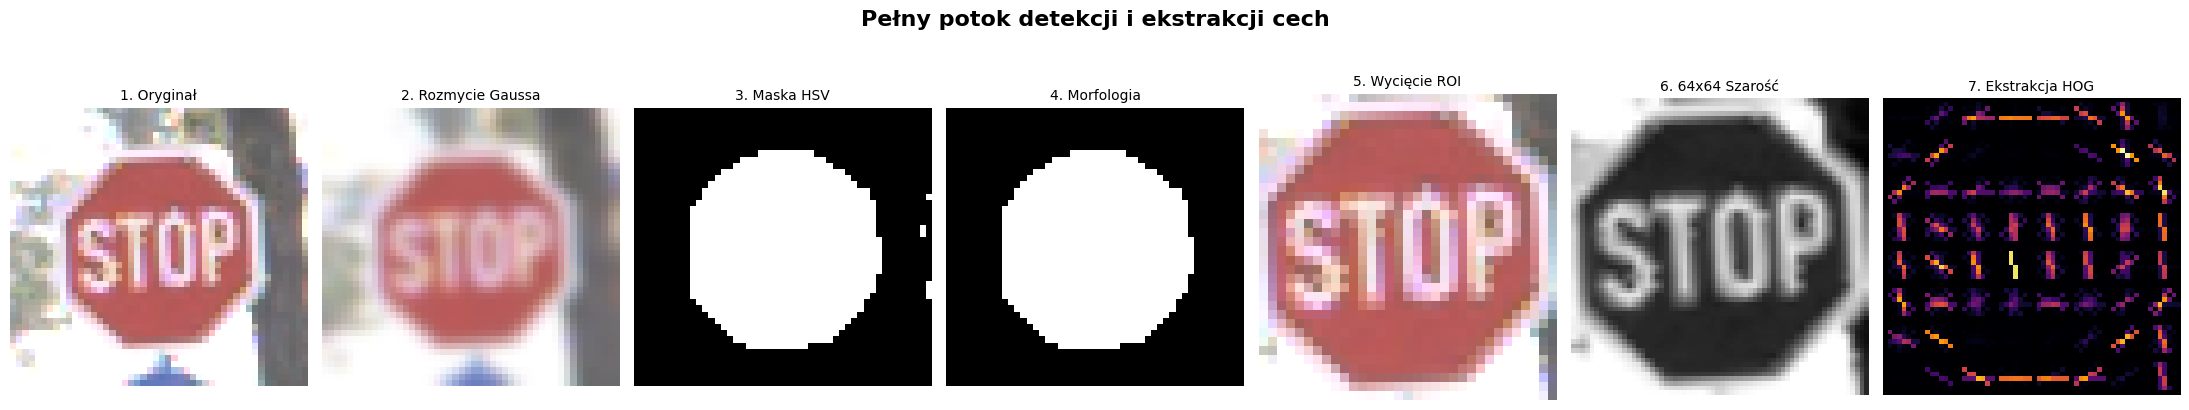

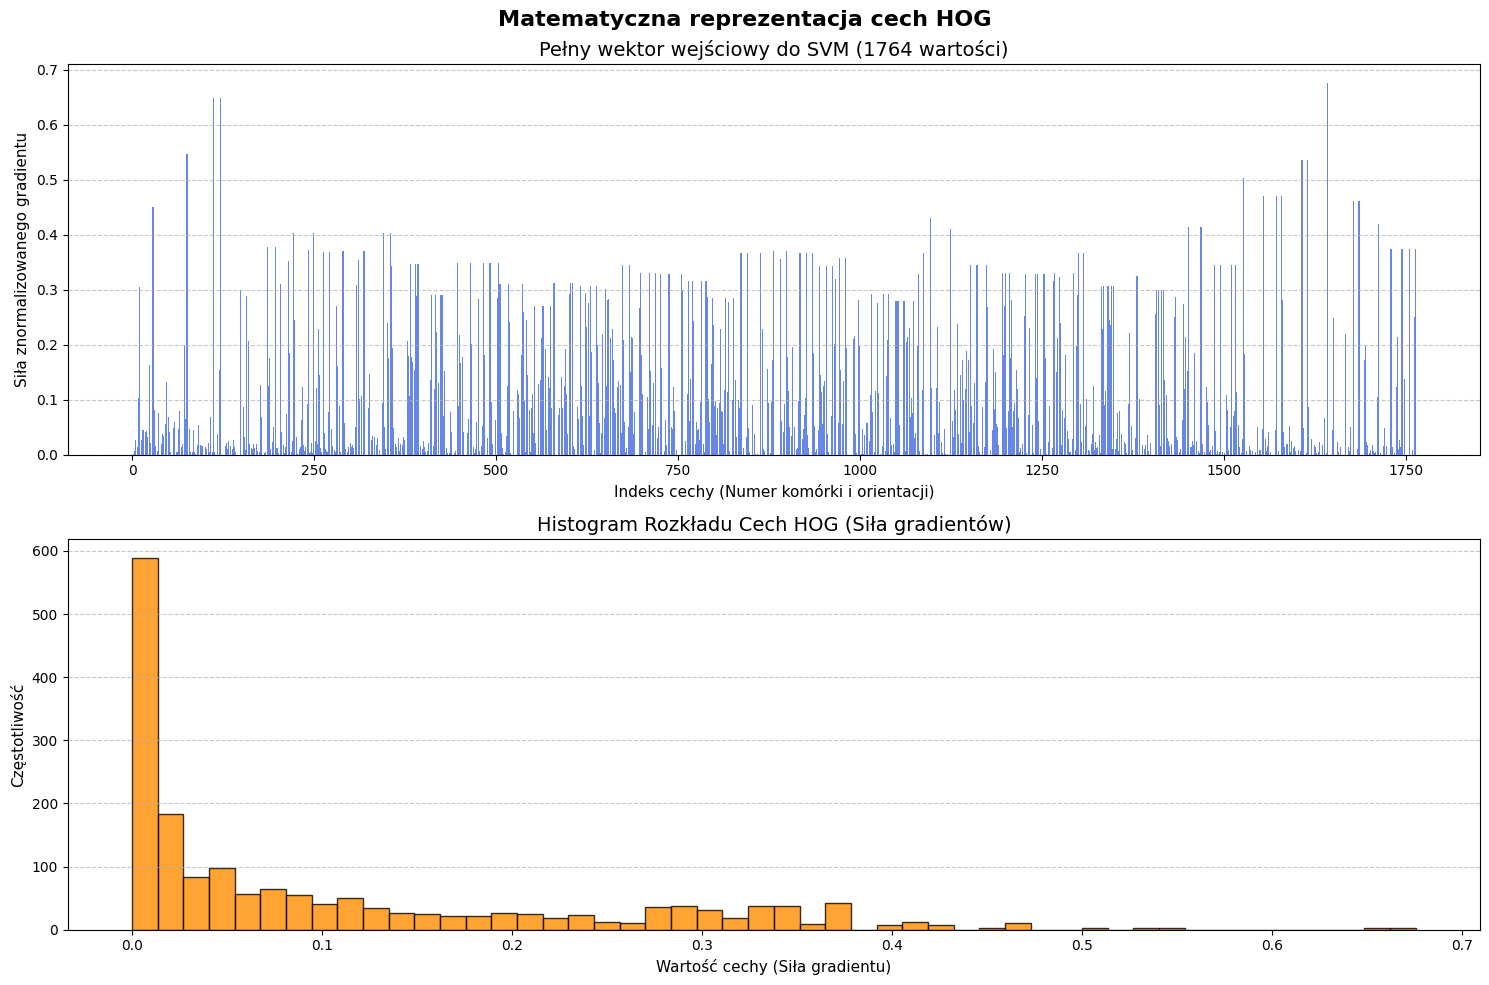

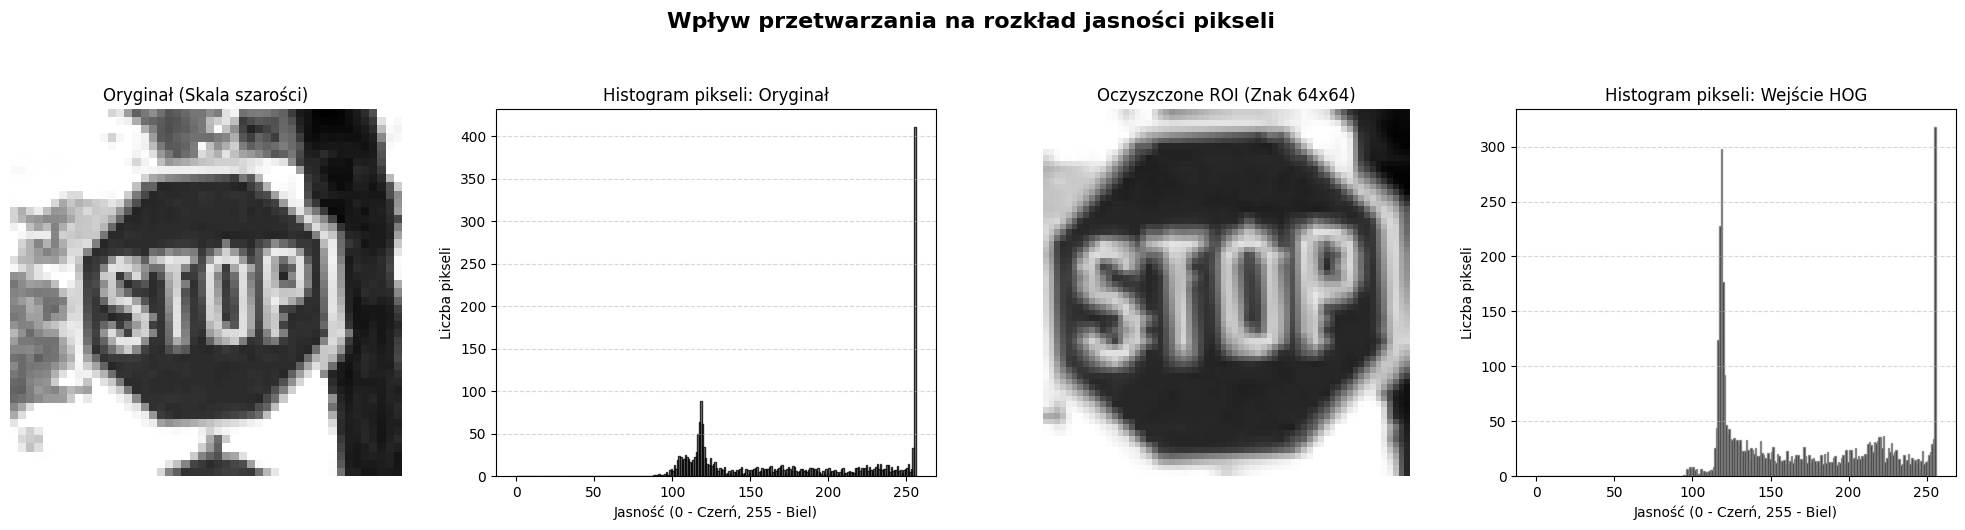

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import sys

# --- KONFIGURACJA ---
IMG_SIZE = (64, 64)
# Upewnij się, że ścieżka do zdjęcia jest poprawna! 
image_path = '../data/selected_signs/stop/00014_00000_00000.png' 

def generate_full_pipeline_report(img_path):
    # 1. Wczytanie oryginału
    img = cv2.imread(img_path)
    if img is None:
        print(f"Błąd: Nie znaleziono obrazu pod ścieżką: {img_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Kopia oryginalnego obrazu w skali szarości specjalnie dla pierwszego histogramu
    original_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ==========================================
    # ETAP 1: DETEKCJA (Odszumianie i Maskowanie)
    # ==========================================
    img_blurred = cv2.GaussianBlur(img, (5, 5), 0)
    img_blurred_rgb = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2RGB)

    hsv = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2HSV)
    
    lower_red1, upper_red1 = np.array([0, 30, 40]), np.array([10, 255, 255])
    lower_red2, upper_red2 = np.array([160, 30, 40]), np.array([180, 255, 255])
    lower_yellow, upper_yellow = np.array([20, 100, 100]), np.array([35, 255, 255])

    mask_combined = cv2.inRange(hsv, lower_red1, upper_red1) + \
                    cv2.inRange(hsv, lower_red2, upper_red2) + \
                    cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    kernel_open = np.ones((3, 3), np.uint8)
    kernel_close = np.ones((7, 7), np.uint8)
    mask_clean = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN, kernel_open)
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_close)

    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        margin = int(0.05 * w)
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img.shape[1], x + w + margin), min(img.shape[0], y + h + margin)
        roi = img[y1:y2, x1:x2]
    else:
        roi = img.copy() 
        
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    # ==========================================
    # ETAP 2: KLASYFIKACJA (Przygotowanie i HOG)
    # ==========================================
    img_resized = cv2.resize(roi, IMG_SIZE)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), block_norm='L2-Hys',
                              visualize=True)

    # ZAPIS WARTOŚCI DO PLIKU TXT
    txt_filename = 'pelny_wektor_hog_zalacznik.txt'
    with open(txt_filename, 'w') as f:
        f.write(f"DOKUMENTACJA PROJEKTU: Wektor cech HOG\n")
        f.write(f"Wymiary obrazu wejściowego: {IMG_SIZE}\n")
        f.write(f"Całkowita liczba wygenerowanych cech: {len(features)}\n")
        f.write("="*70 + "\n\n")
        np.set_printoptions(threshold=sys.maxsize, linewidth=100, precision=4)
        f.write(np.array2string(features, separator=', '))
        
    print(f"[SUKCES] Zapisano wartości do pliku: {txt_filename}\n")

    # ==========================================
    # WIZUALIZACJA 1: PEŁNY POTOK OBRAZU (7 ETAPÓW)
    # ==========================================
    fig1, axes1 = plt.subplots(1, 7, figsize=(22, 4))
    fig1.suptitle('Pełny potok detekcji i ekstrakcji cech', fontsize=16, fontweight='bold', y=1.05)
    
    axes1[0].imshow(img_rgb)
    axes1[0].set_title("1. Oryginał", fontsize=10)
    axes1[0].axis('off')

    axes1[1].imshow(img_blurred_rgb)
    axes1[1].set_title("2. Rozmycie Gaussa", fontsize=10)
    axes1[1].axis('off')

    axes1[2].imshow(mask_combined, cmap='gray')
    axes1[2].set_title("3. Maska HSV", fontsize=10)
    axes1[2].axis('off')

    axes1[3].imshow(mask_clean, cmap='gray')
    axes1[3].set_title("4. Morfologia", fontsize=10)
    axes1[3].axis('off')

    axes1[4].imshow(roi_rgb)
    axes1[4].set_title("5. Wycięcie ROI", fontsize=10)
    axes1[4].axis('off')

    axes1[5].imshow(gray, cmap='gray')
    axes1[5].set_title(f"6. 64x64 Szarość", fontsize=10)
    axes1[5].axis('off')

    axes1[6].imshow(hog_image, cmap='inferno')
    axes1[6].set_title("7. Ekstrakcja HOG", fontsize=10)
    axes1[6].axis('off')

    plt.tight_layout()

    # ==========================================
    # WIZUALIZACJA 2: WYKRESY WEKTORA I HISTOGRAM HOG
    # ==========================================
    fig2, axes2 = plt.subplots(2, 1, figsize=(15, 10))
    fig2.suptitle('Matematyczna reprezentacja cech HOG', fontsize=16, fontweight='bold')

    axes2[0].bar(range(len(features)), features, color='royalblue', alpha=0.8)
    axes2[0].set_title(f'Pełny wektor wejściowy do SVM ({len(features)} wartości)', fontsize=14)
    axes2[0].set_xlabel('Indeks cechy (Numer komórki i orientacji)', fontsize=11)
    axes2[0].set_ylabel('Siła znormalizowanego gradientu', fontsize=11)
    axes2[0].grid(axis='y', linestyle='--', alpha=0.7)

    axes2[1].hist(features, bins=50, color='darkorange', edgecolor='black', alpha=0.8)
    axes2[1].set_title('Histogram Rozkładu Cech HOG (Siła gradientów)', fontsize=14)
    axes2[1].set_xlabel('Wartość cechy (Siła gradientu)', fontsize=11)
    axes2[1].set_ylabel('Częstotliwość', fontsize=11)
    axes2[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()

    # ==========================================
    # NOWOŚĆ - WIZUALIZACJA 3: HISTOGRAMY OBRAZU (Przed vs Po)
    # ==========================================
    fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
    fig3.suptitle('Wpływ przetwarzania na rozkład jasności pikseli', fontsize=16, fontweight='bold', y=1.05)

    # 1. Obraz przed
    axes3[0].imshow(original_gray, cmap='gray')
    axes3[0].set_title("Oryginał (Skala szarości)", fontsize=12)
    axes3[0].axis('off')

    # 2. Histogram przed (Ravel 'spłaszcza' macierz 2D do 1D żeby dało się policzyć histogram)
    axes3[1].hist(original_gray.ravel(), bins=256, range=[0, 256], color='gray', edgecolor='black', alpha=0.8)
    axes3[1].set_title('Histogram pikseli: Oryginał', fontsize=12)
    axes3[1].set_xlabel('Jasność (0 - Czerń, 255 - Biel)')
    axes3[1].set_ylabel('Liczba pikseli')
    axes3[1].grid(axis='y', linestyle='--', alpha=0.5)

    # 3. Obraz po
    axes3[2].imshow(gray, cmap='gray')
    axes3[2].set_title("Oczyszczone ROI (Znak 64x64)", fontsize=12)
    axes3[2].axis('off')

    # 4. Histogram po
    axes3[3].hist(gray.ravel(), bins=256, range=[0, 256], color='black', edgecolor='gray', alpha=0.8)
    axes3[3].set_title('Histogram pikseli: Wejście HOG', fontsize=12)
    axes3[3].set_xlabel('Jasność (0 - Czerń, 255 - Biel)')
    axes3[3].set_ylabel('Liczba pikseli')
    axes3[3].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show() # Teraz pokaże na raz 3 okienka z wykresami

# Uruchomienie funkcji
generate_full_pipeline_report(image_path)

Rozpoczynam zaawansowane przetwarzanie zdjęć i ekstrakcję HOG...
-> Przetwarzanie klasy: Droga_z_pierwszenstwem (2100 zdjęć)...
-> Przetwarzanie klasy: Ograniczenie_30 (2220 zdjęć)...
-> Przetwarzanie klasy: Stop (780 zdjęć)...
-> Przetwarzanie klasy: Ustap_pierwszenstwa (2160 zdjęć)...
-> Przetwarzanie klasy: Zakaz_wjazdu (1110 zdjęć)...

[INFO] Zakończono przygotowanie. Przetworzono łącznie 8365 zdjęć.

Dzielenie danych na zbiór treningowy (80%) i testowy (20%)...
Trenuję klasyfikator SVM (to może chwilę potrwać)...
Testuję model na danych walidacyjnych...

[WYNIK] Ogólna skuteczność modelu (Accuracy): 90.44%

                        precision    recall  f1-score   support

Droga_z_pierwszenstwem       0.82      0.86      0.84       428
       Ograniczenie_30       0.93      0.93      0.93       430
                  Stop       0.99      0.97      0.98       160
   Ustap_pierwszenstwa       0.91      0.87      0.89       431
          Zakaz_wjazdu       0.96      0.95      0.96      

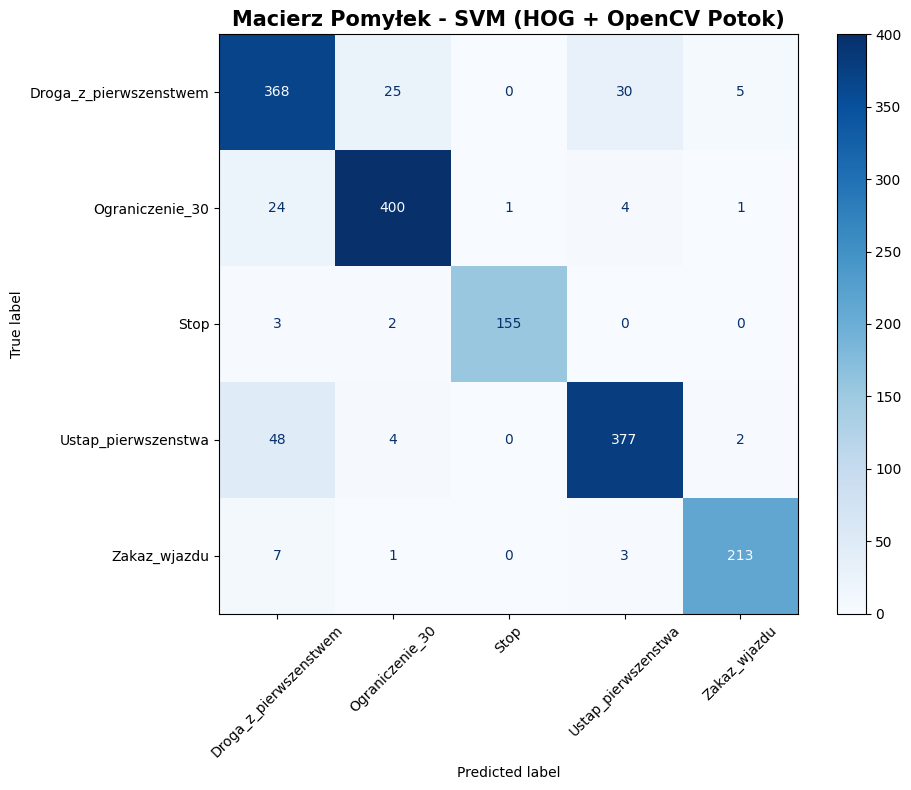

Generuję podgląd predykcji...


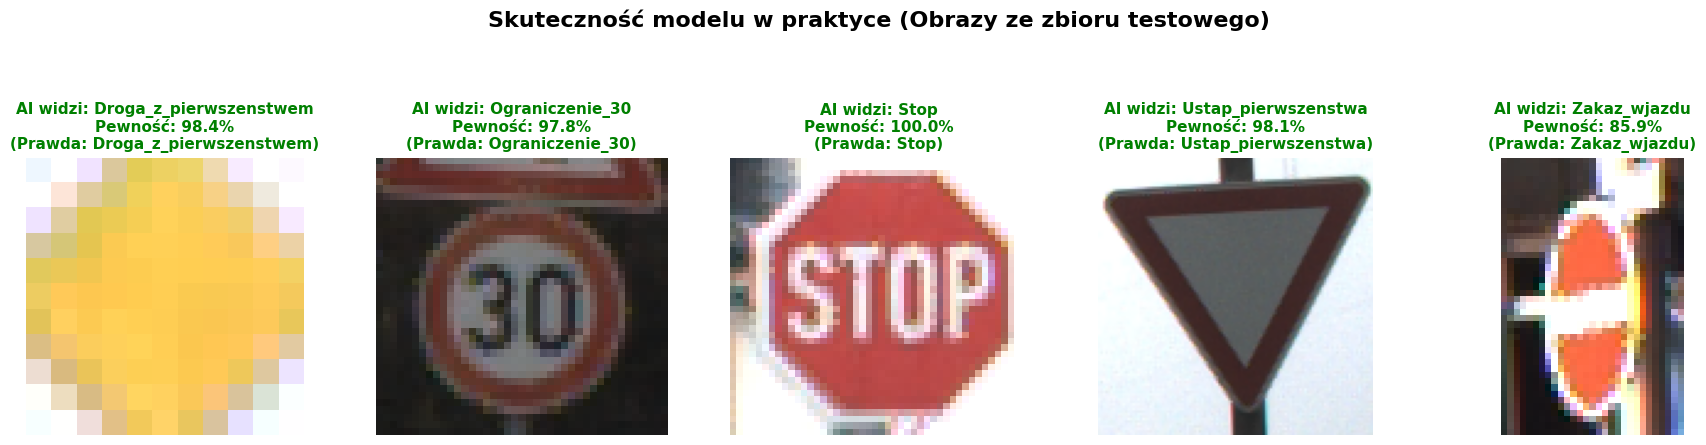

In [2]:
# OSTATECZNY KOD TRENUJĄCY (Potok Detekcji + Zabezpieczenia + Zapis + Macierz + Wizualizacja Predykcji)
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib 

# --- KONFIGURACJA ---
data_dir = '../data/selected_signs'
model_save_path = '../models/svm_model.pkl' 
IMG_SIZE = (64, 64) 

X = [] # Wektory cech HOG
labels = [] # Etykiety klas
rois_for_display = [] # NOWOŚĆ: Zapisujemy kolorowe wycinki znaków, żeby je potem pokazać!

print("Rozpoczynam zaawansowane przetwarzanie zdjęć i ekstrakcję HOG...")

os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    
    if os.path.isdir(class_path):
        images_in_class = os.listdir(class_path)
        print(f"-> Przetwarzanie klasy: {class_name} ({len(images_in_class)} zdjęć)...")
        
        for img_name in images_in_class:
            img_path = os.path.join(class_path, img_name)
            
            img = cv2.imread(img_path)
            
            if img is None or img.size == 0:
                print(f"[UWAGA] Pominięto uszkodzony plik: {img_name}")
                continue
                
            try:
                # ==========================================
                # ETAP 1: ODSZUMIANIE I MASKOWANIE
                # ==========================================
                img_blurred = cv2.GaussianBlur(img, (5, 5), 0)
                
                hsv = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2HSV)
                lower_red1, upper_red1 = np.array([0, 30, 40]), np.array([10, 255, 255])
                lower_red2, upper_red2 = np.array([160, 30, 40]), np.array([180, 255, 255])
                lower_yellow, upper_yellow = np.array([20, 100, 100]), np.array([35, 255, 255])

                mask_combined = cv2.inRange(hsv, lower_red1, upper_red1) + \
                                cv2.inRange(hsv, lower_red2, upper_red2) + \
                                cv2.inRange(hsv, lower_yellow, upper_yellow)
                
                kernel_open = np.ones((3, 3), np.uint8)
                kernel_close = np.ones((7, 7), np.uint8)
                mask_clean = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN, kernel_open)
                mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_close)

                contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                if contours:
                    largest_contour = max(contours, key=cv2.contourArea)
                    bx, by, bw, bh = cv2.boundingRect(largest_contour)
                    margin = int(0.05 * bw)
                    x1, y1 = max(0, bx - margin), max(0, by - margin)
                    x2, y2 = min(img.shape[1], bx + bw + margin), min(img.shape[0], by + bh + margin)
                    roi = img[y1:y2, x1:x2]
                    
                    if roi.size == 0:
                        roi = img.copy()
                else:
                    roi = img.copy()

                # ==========================================
                # ETAP 2: KLASYFIKACJA I ZAPIS
                # ==========================================
                img_resized = cv2.resize(roi, IMG_SIZE)
                gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
                
                features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
                
                X.append(features)
                labels.append(class_name)
                # NOWOŚĆ: Zapisujemy ładny, kolorowy wycinek znaku (konwersja na RGB dla wykresu)
                rois_for_display.append(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
                
            except Exception as e:
                continue

X = np.array(X)
y = np.array(labels) 
# Zmieniamy też listę obrazków na format zrozumiały dla dzielnika danych
rois_for_display = np.array(rois_for_display, dtype=object) 

print(f"\n[INFO] Zakończono przygotowanie. Przetworzono łącznie {len(X)} zdjęć.")

# --- TRENING MODELU ---
print("\nDzielenie danych na zbiór treningowy (80%) i testowy (20%)...")
# NOWOŚĆ: Dzielimy na 3 części: Cechy(X), Etykiety(y) oraz Obrazki (rois)
X_train, X_test, y_train, y_test, rois_train, rois_test = train_test_split(
    X, y, rois_for_display, test_size=0.2, random_state=42)

print("Trenuję klasyfikator SVM (to może chwilę potrwać)...")
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# --- EWALUACJA ---
print("Testuję model na danych walidacyjnych...")
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n[WYNIK] Ogólna skuteczność modelu (Accuracy): {accuracy * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# --- ZAPIS MODELU ---
joblib.dump(svm_model, model_save_path)
print(f"[SUKCES] Gotowy model SVM został trwale zapisany w: {model_save_path}")

# ==========================================
# WIZUALIZACJA 1: MACIERZ POMYŁEK
# ==========================================
print("\nGeneruję Macierz Pomyłek...")
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')
plt.title('Macierz Pomyłek - SVM (HOG + OpenCV Potok)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# WIZUALIZACJA 2: GALERIA PREDYKCJI (Po 1 z każdej klasy)
# ==========================================
print("Generuję podgląd predykcji...")
unique_classes = np.unique(y_test)
num_classes = len(unique_classes)

fig2, axes2 = plt.subplots(1, num_classes, figsize=(18, 4))
fig2.suptitle('Skuteczność modelu w praktyce (Obrazy ze zbioru testowego)', fontsize=16, fontweight='bold', y=1.1)

for i, cls in enumerate(unique_classes):
    # Szukamy pierwszego zdjęcia w zbiorze testowym, które należy do danej klasy
    idx = np.where(y_test == cls)[0][0]
    
    feature_vector = X_test[idx].reshape(1, -1) # Pobieramy wektor HOG
    true_label = y_test[idx]                    # Pobieramy prawdziwą odpowiedź
    display_img = rois_test[idx]                # Pobieramy kolorowe zdjęcie do wyświetlenia
    
    # Model zgaduje i podaje prawdopodobieństwo (Accuracy dla tego konkretnego zdjęcia)
    prediction = svm_model.predict(feature_vector)[0]
    probabilities = svm_model.predict_proba(feature_vector)[0]
    confidence = np.max(probabilities) * 100
    
    # Formatowanie koloru tytułu (Zielony = Zgadł, Czerwony = Pomylił się)
    title_color = 'green' if prediction == true_label else 'red'
    
    ax = axes2[i]
    ax.imshow(display_img)
    ax.set_title(f"AI widzi: {prediction}\nPewność: {confidence:.1f}%\n(Prawda: {true_label})", 
                 fontsize=11, color=title_color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()